In [1]:
from molvs import standardize_smiles
from rdkit import Chem
import pandas as pd
import numpy as np

In [2]:
SolCbio3Database = pd.read_csv('SolCbio3Database_merged.csv')
literature = pd.read_excel('SolCbio3Database.xlsx')
wiki_ps0 = pd.read_csv('Avdeef_sol_db_298K.csv')
AqSolDB = pd.read_csv('AqSolDBc_noions.csv')
BigSolDB = pd.read_csv('BigSolDBv2.0_w_298K_noions.csv')

In [3]:
SolCbio3Database['SMILES_standard'] = SolCbio3Database['smiles'].astype(str).apply(lambda x: standardize_smiles(x))
literature['SMILES_standard'] = literature['smiles'].astype(str).apply(lambda x: standardize_smiles(x))
wiki_ps0['SMILES_standard'] = wiki_ps0['SMILES_standard'].astype(str).apply(lambda x: standardize_smiles(x))
AqSolDB['SMILES_standard'] = AqSolDB['SMILES_standard'].astype(str).apply(lambda x: standardize_smiles(x))
BigSolDB['SMILES_standard'] = BigSolDB['SMILES_standard'].astype(str).apply(lambda x: standardize_smiles(x))

In [4]:
SolCbio3Database_prepared = SolCbio3Database[['SMILES_standard', 'logS']].rename(columns = {
    'SMILES_standard': 'smiles',
    'logS': 'logS'})

literature_prepared = literature[['SMILES_standard', 'logS']].rename(columns = {
    'SMILES_standard': 'smiles',
    'logS': 'logS'})

wiki_ps0_prepared = wiki_ps0[['SMILES_standard','logS0_25']].rename(columns = {
    'SMILES_standard': 'smiles',
    'logS0_25': 'logS'})

AqSolDB_prepared = AqSolDB[['SMILES_standard','Solubility']].rename(columns = {
    'SMILES_standard': 'smiles',
    'Solubility': 'logS'})

BigSolDB_prepared = BigSolDB[['SMILES_standard','LogS(mol/L)']].rename(columns = {
    'SMILES_standard': 'smiles',
    'LogS(mol/L)': 'logS'})

In [22]:
def merge_common_smiles(df1, df2, df3, df4, df5,
                                     smiles_col='smiles', value_col='logS'):
    """
    Merge DataFrames based on SMILES that appear in df1 and in at least one
    of df2, df3, or df4. The output includes logS from all four DataFrames
    (NaN if missing) and the standard deviation across non‑NaN values.

    Parameters
    ----------
    df1, df2, df3, df4 : pandas.DataFrame
        Each must contain a column with SMILES and a column with logS values.
    smiles_col : str, default 'SMILES'
        Name of the SMILES column.
    value_col : str, default 'logS'
        Name of the logS column.

    Returns
    -------
    pandas.DataFrame
        Columns: 'smiles', 'logS_df1', 'logS_df2', 'logS_df3', 'logS_df4', 'sd'
    """
    # Standardise column names
    def prepare(df):
        return df[[smiles_col, value_col]].copy().rename(
            columns={smiles_col: 'smiles', value_col: 'logS'}
        )

    d1 = prepare(df1)
    d2 = prepare(df2)
    d3 = prepare(df3)
    d4 = prepare(df4)
    d5 = prepare(df5)

    # Get sets of SMILES
    s1 = set(d1['smiles'])
    s2 = set(d2['smiles'])
    s3 = set(d3['smiles'])
    s4 = set(d4['smiles'])
    s5 = set(d5['smiles'])

    # SMILES that are in df1 and also in at least one other
    others = s2 | s3 | s4 | s5
    target_smiles = s1 & others   # intersection

    # Build rows
    rows = []
    for smi in target_smiles:
        row = {'smiles': smi}
        # Get logS from each dataframe, if present
        row['logS_df1'] = d1.loc[d1['smiles'] == smi, 'logS'].iloc[0]  # always exists
        row['logS_df2'] = d2.loc[d2['smiles'] == smi, 'logS'].iloc[0] if smi in s2 else np.nan
        row['logS_df3'] = d3.loc[d3['smiles'] == smi, 'logS'].iloc[0] if smi in s3 else np.nan
        row['logS_df4'] = d4.loc[d4['smiles'] == smi, 'logS'].iloc[0] if smi in s4 else np.nan
        row['logS_df5'] = d5.loc[d5['smiles'] == smi, 'logS'].iloc[0] if smi in s5 else np.nan
        rows.append(row)

    result_df = pd.DataFrame(rows)

    # Add standard deviation (sample std, ignoring NaN)
    log_cols = ['logS_df1', 'logS_df2', 'logS_df3', 'logS_df4', 'logS_df5']
    nan_count = result_df[log_cols].isna().sum(axis=1)
    result_df = result_df[nan_count < 2].reset_index(drop=True)
    

    return result_df

In [23]:
overlapped_logS = merge_common_smiles(SolCbio3Database_prepared, literature_prepared, wiki_ps0_prepared, AqSolDB_prepared, BigSolDB_prepared)
overlapped_logS = overlapped_logS.rename(columns = {
        'logS_df2': 'logS_literature',
        'logS_df3': 'logS_wiki_ps0',
        'logS_df4': 'logS_AqSolDB',
        'logS_df5': 'logS_BigSolDB'}).drop(columns = ['logS_df1'])

overlapped_logS['sd'] = overlapped_logS.iloc[:, 1:5].std(axis=1, ddof=1)

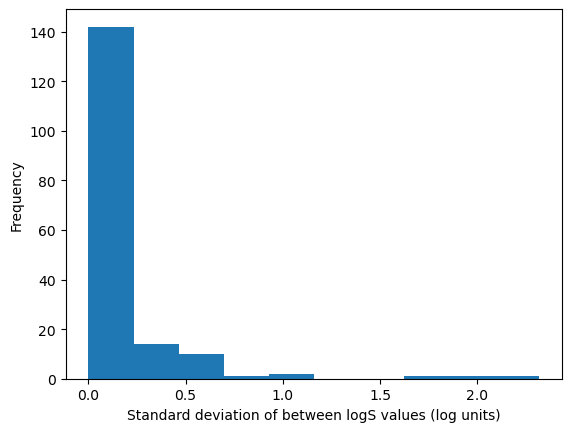

In [28]:
import matplotlib.pyplot as plt

plt.hist(overlapped_logS['sd'])

# Add styling and show the plot
plt.xlabel("Standard deviation of between logS values (log units)")
plt.ylabel("Frequency")
plt.savefig('overlapped_histogram.pdf', format='pdf', dpi=500, bbox_inches='tight')
plt.savefig('overlapped_histogram.png', format='png', dpi=500, bbox_inches='tight')
plt.show()

overlapped_logS.to_csv('overlapped_logS.csv',index=False)

In [32]:
overlapped_logS[overlapped_logS['sd'] > 0.5]

,smiles,logS_literature,logS_wiki_ps0,logS_AqSolDB,logS_BigSolDB,sd
4,CCCCCC=O,-1.30,NaN,-5.412222,-1.496218,2.319625
11,O=C(c1ccccc1)c1ccccc1,-3.12,-3.12,-3.882203,-0.206747,1.623909
17,Clc1ccc(-c2ccccc2)cc1Cl,-7.44,-6.37,-6.389900,NaN,0.612101
27,COP(=S)(OC)Oc1cc(Cl)c(Cl)cc1Cl,-3.90,-5.71,-5.507200,NaN,0.991659
30,c1ccc(-c2ccc(-c3ccccc3)cc2)cc1,-7.11,-7.08,-6.183336,NaN,0.526563
43,CC(C)OC(=O)C(O)(c1ccc(Br)cc1)c1ccc(Br)cc1,-4.93,-6.60,-4.933000,NaN,0.963310
50,Clc1ccc(Cl)c(-c2ccc(Cl)c(Cl)c2Cl)c1,-6.97,-7.88,-7.910000,NaN,0.534260
64,Cc1cc(=O)n(-c2ccccc2)n1C,-0.56,0.51,-0.564200,NaN,0.618981
94,Clc1ccc(-c2ccc(Cl)c(Cl)c2Cl)c(Cl)c1Cl,-7.79,-7.98,-8.780000,NaN,0.525389
109,Clc1ccc(-c2ccc(Cl)c(Cl)c2)c(Cl)c1,-6.89,-7.77,-6.899500,NaN,0.505348


In [31]:
overlapped_logS

,smiles,logS_literature,logS_wiki_ps0,logS_AqSolDB,logS_BigSolDB,sd
0,COP(=S)(OC)Oc1cc(Cl)c(Br)cc1Cl,-6.09,-6.08,-6.086400,NaN,0.005065
1,c1cc2cccc3c4cccc5cccc(c(c1)c23)c54,-8.80,-8.75,-8.700000,NaN,0.050000
2,OCCc1ccccc1,-0.74,NaN,-0.785924,-0.553202,0.123263
3,Cc1ccc2cc3ccccc3cc2c1,-6.69,-6.69,-6.955500,NaN,0.153286
4,CCCCCC=O,-1.30,NaN,-5.412222,-1.496218,2.319625
...,...,...,...,...,...,...
167,c1ccc2c(c1)ccc1ccccc12,-5.21,-5.23,-5.190300,NaN,0.019850
168,CC(N)=O,1.58,1.13,1.580800,1.643807,0.237655
169,O=Cc1ccccc1,-1.19,NaN,-1.209572,-0.894124,0.176745
170,Clc1ccc(-c2cc(Cl)c(Cl)cc2Cl)cc1Cl,-7.39,-7.36,-7.386700,NaN,0.016451
